In [1]:
import pandas as pd
from pandas import DataFrame
from pandas.plotting import scatter_matrix

from src.data_loader import data_loader

houses_raw = data_loader()

In [2]:
houses_raw.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


We can add some features which might be helpful and make our data more descriptive.

In [3]:
houses_added_features = houses_raw.copy()
houses_added_features.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
#Total area of the house
houses_added_features["TotalSF"] = houses_added_features["TotalBsmtSF"] + houses_added_features["1stFlrSF"] + houses_added_features["2ndFlrSF"]

#House age
houses_added_features["HouseAge"] = houses_added_features["YrSold"] - houses_added_features["YearBuilt"]
houses_added_features["RemodelAge"] = houses_added_features["YrSold"] - houses_added_features["YearRemodAdd"]
houses_added_features["WasRemodeled"] = (houses_added_features["YearBuilt"] != houses_added_features["YearRemodAdd"]).astype(int)

#łazienki
houses_added_features["TotalBath"] = (houses_added_features["FullBath"] +
                                       houses_added_features["HalfBath"] * 0.5 +
                                       houses_added_features["BsmtFullBath"] +
                                       houses_added_features["BsmtHalfBath"] * 0.5)

#garaż
houses_added_features["GarageAreaPerCar"] = houses_added_features["GarageArea"] / (houses_added_features["GarageCars"] + 1)

#udogodnienia
houses_added_features["HasPool"] = (houses_added_features["PoolArea"] > 0).astype(int)
houses_added_features["HasBasement"] = (houses_added_features["TotalBsmtSF"] > 0).astype(int)
houses_added_features["HasGarage"] = (houses_added_features["GarageArea"] > 0).astype(int)
houses_added_features["HasFireplace"] = (houses_added_features["Fireplaces"] > 0).astype(int)

#jakość nieruchomości
houses_added_features["QualXSF"] = houses_added_features["OverallQual"] * houses_added_features["GrLivArea"]

In [6]:
houses_added_features[["TotalSF","HouseAge","RemodelAge","WasRemodeled","TotalBath","GarageAreaPerCar","HasPool","HasBasement","HasGarage","HasFireplace","QualXSF"]]

,TotalSF,HouseAge,RemodelAge,WasRemodeled,TotalBath,GarageAreaPerCar,HasPool,HasBasement,HasGarage,HasFireplace,QualXSF
0,2566,5,5,0,3.5,182.666667,0,1,1,0,11970
1,2524,31,31,0,2.5,153.333333,0,1,1,1,7572
2,2706,7,6,1,3.5,202.666667,0,1,1,1,12502
3,2473,91,36,1,2.0,160.500000,0,1,1,1,12019
4,3343,8,8,0,3.5,209.000000,0,1,1,1,17584
...,...,...,...,...,...,...,...,...,...,...,...
1455,2600,8,7,1,2.5,153.333333,0,1,1,1,9882
1456,3615,32,22,1,3.0,166.666667,0,1,1,1,12438
1457,3492,69,4,1,2.0,126.000000,0,1,1,1,16380
1458,2156,60,14,1,2.0,120.000000,0,1,1,0,5390


<Axes: ylabel='None'>

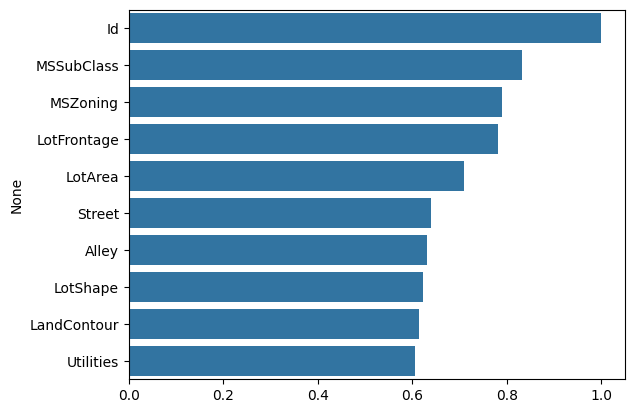

In [11]:
import seaborn as sns

corr_matrix = houses_added_features.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_added_features.columns[:10])


None from added features are valuable for our model.